## Sur les allergies

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Importe le csv des Tenracs, allergenes et allergiques
bd = pd.read_csv('./tenrac.csv')
bdAllergies = pd.read_csv('./allergenes.csv')
bdAllergiques = pd.read_csv('./allergiques.csv')

In [50]:
#on assure format correct sans espaces ou guillemets
bdAllergies.columns = bdAllergies.columns.str.strip()
bdAllergies['nomAller0'] = bdAllergies['nomAller0'].str.strip("'")
bdAllergies = bdAllergies.rename(columns={'nomAller0': 'nomAller'})

In [51]:
bdAllergiques.columns = bdAllergiques.columns.str.strip()

In [56]:
#On fait une jointure pour pouvoir utiliser information de plusieurs tables 
#equivalent a une requete SQL avec JOIN entre tables bdAllergenes et bdAllergiques)

allergiesJoin = bdAllergiques.merge(bdAllergies, on='idAller', how='left')
allergiesJoin.axes #on obtient une table avec toute l'information dont on aura besoin

[RangeIndex(start=0, stop=317883, step=1),
 Index(['idTenrac', 'idAller', 'nomAller'], dtype='object')]

In [53]:
# Pour repondre a la question : combien a t-il d'allergiques pour chaque allergie?
# on produit une table avec tout les modalites de bdAllergenes 
#  Remarque : il peut avoir une presonne allergique a plus d'une allergie

allergieCount = allergiesJoin['nomAller'].value_counts()
print(allergieCount) 

nomAller
TRAUMATISME GUSTATIF DU HARICOT FRAIS'     484
MORT CAUSEE PAR HARICOT BIO'               484
REACTION CUTANEE A HARICOT SELECTION'      484
GONFLEMENT A CAUSE DE HARICOT PREMIUM'     484
MORT CAUSEE PAR BROCOLI PREMIUM'           482
                                          ... 
REACTION CUTANEE A CAROTTE PREMIUM'        221
GONFLEMENT A CAUSE DE CAROTTE FRAIS'       221
MORT CAUSEE PAR OLIVE FRIT'                206
TRAUMATISME GUSTATIF DU OLIVE SNACKE'      206
MORT CAUSEE PAR OLIVE SNACKE'              113
Name: count, Length: 743, dtype: int64


In [62]:
#on selectionne les 10 allergies plus frequentes
top10Allergies = allergieCount.head(10)
#print(topAllergies)

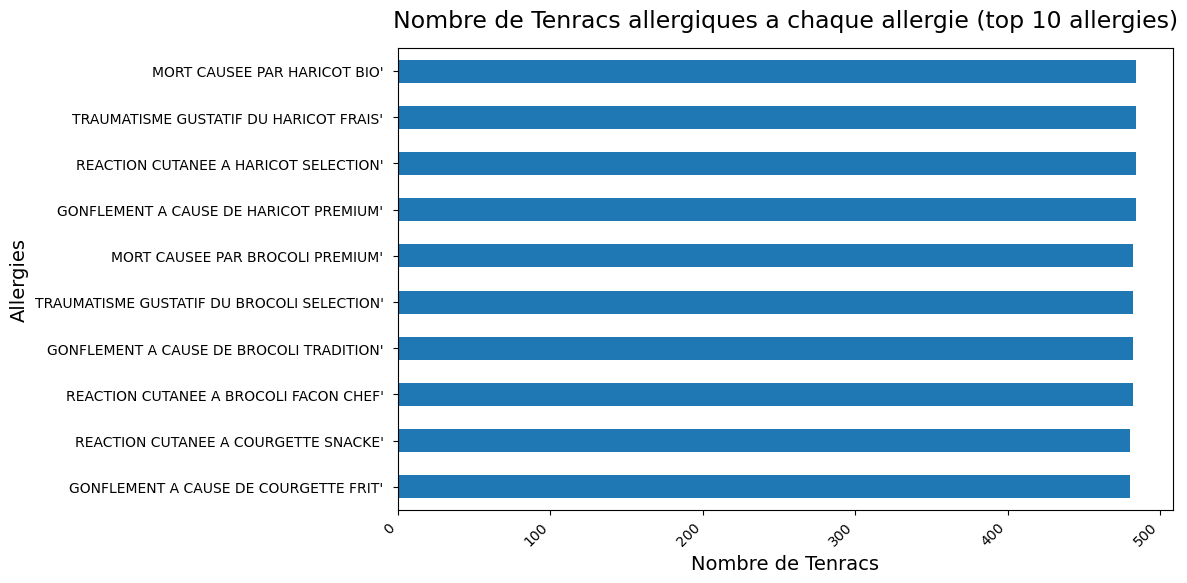

In [103]:
#On affiche le diagram en barres horizontales
top10Allergies.sort_values().plot(kind='barh', figsize=(10,6))
plt.xlabel('Nombre de Tenracs', fontsize=14)
plt.ylabel('Allergies', fontsize=14)
plt.title('Nombre de Tenracs allergiques a chaque allergie (top 10 allergies)', fontsize=17, pad=15)

# Incline les grades à 35° alignées à droite
plt.tick_params(axis='x', rotation=45)
plt.xticks(ha='right')

plt.show()

In [99]:
#On cree une nouvelle attribut avec les legumes pour regroupe les resultat par legumes
setLegumes = {
    'HARICOT', 'BROCOLI', 'CHOU', 'ASPERGE', 'CHAMPIGNON',
    'POIREAU', 'POTIRON', 'AVOCAT', 'CONCOMBRE', 'POIVRON',
    'EPINARD', 'AUBERGINE', 'ARTICHAUT', 'COURGETTE',
    'OIGNON', 'OLIVE', 'CAROTTE'
}

#cherche si une legume de la list de legumes se trouve sinon on reenvoie None
def getLegume(text):
    if pd.isna(text):
        return None
    
    mots = text.upper().split()
    
    for str in mots:
        if str in setLegumes:
            return str
    return None
    
#On cree la colonnne Legume a partir du nom des allergies qui sont lie a cettes legumes
allergiesJoin['Legume'] = allergiesJoin['nomAller'].apply(getLegume)

In [97]:
#print(allergiesJoin['legume'])
# On affiche les modalites et effectifs de chaque legume
legumesCount = allergiesJoin['Legume'].value_counts()
print(legumesCount)

Legume
HARICOT       19304
BROCOLI       19294
CHOU          19182
CHAMPIGNON    19148
POIREAU       19026
ASPERGE       19014
AVOCAT        18974
POIVRON       18969
POTIRON       18964
EPINARD       18905
CONCOMBRE     18866
OIGNON        18814
ARTICHAUT     18768
COURGETTE     18762
AUBERGINE     18270
OLIVE         17600
CAROTTE       15914
Name: count, dtype: int64


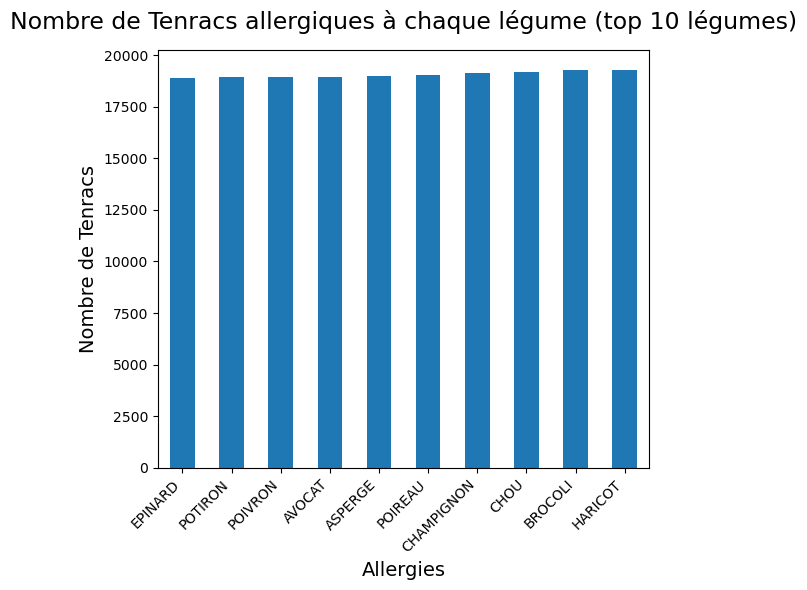

In [112]:
#On slectionne les top 10 pour visualise les plus relevant
top10Legumes = legumesCount.head(10)
#print(top10Legumes)

#On affiche le diagram en barres verticales
top10Legumes.sort_values().plot(kind='bar', figsize=(6,6))
plt.xlabel('Allergies', fontsize=14)
plt.ylabel('Nombre de Tenracs', fontsize=14)
plt.title('Nombre de Tenracs allergiques à chaque légume (top 10 légumes)', fontsize=17, pad=15)

# Incline les grades à 35° alignées à droite
plt.tick_params(axis='x', rotation=45)
plt.xticks(ha='right')

plt.tight_layout()
plt.show()